# Flickr30k Entities — Phrase Grounding Analysis (Part 1)

Loads **Flickr30k Entities** ([Plummer et al. 2015](https://github.com/bryanplummer/flickr30k_entities)):
noun phrases in each caption are linked to bounding boxes in the image.

Cells:
1. Auth
2. Download images (parquet via HF Hub)
3. Download entity annotations (XML + txt from GitHub)
4. **20-image grid** with phrase-grounded bboxes → saved to `outputs/flickr30k_entities_grid.png`
5. Full-dataset scan (single pass ~50 s) — collects all stats
6. Entity type bar chart
7. Boxes / chains / phrases-per-sentence distributions
8. Bbox area / image area distribution
9. % phrases with multiple bboxes / no bbox
10. Co-occurrence heatmap
11. Head-noun vocabulary + word cloud
12. `FlickrEntitiesDataset` class (PyTorch Dataset for training)
13. Summary + write `notes/dataset_stats.md`

In [1]:
# ── 0. Auth & deps ───────────────────────────────────────────────────────────
import os, getpass

if not os.environ.get('HF_TOKEN'):
    os.environ['HF_TOKEN'] = getpass.getpass('Hugging Face token (read scope): ')

In [2]:
# ── 1. Download images (parquet) ─────────────────────────────────────────────
# datasets >= 4.0 no longer runs custom loading scripts, so we bypass
# nlphuji/flickr30k's loading script and hit the auto-generated parquet export.
# Schema: image{bytes,path}, caption[str], sentids[str], split, img_id, filename
from datasets import load_dataset
from huggingface_hub import HfApi, hf_hub_download
import io
from PIL import Image as PILImage

token   = os.environ.get('HF_TOKEN')
repo_id = 'nlphuji/flickr30k'

api      = HfApi(token=token)
pq_names = sorted(
    f for f in api.list_repo_files(
        repo_id, repo_type='dataset', revision='refs/convert/parquet'
    )
    if f.endswith('.parquet')
)
print(f'Found {len(pq_names)} parquet shard(s)')

local_files = [
    hf_hub_download(
        repo_id=repo_id, filename=f,
        repo_type='dataset', revision='refs/convert/parquet', token=token,
    )
    for f in pq_names
]

ds    = load_dataset('parquet', data_files={'data': local_files})
data  = ds['data']
print(ds)
print(f'Rows: {len(data):,}  |  Columns: {data.column_names}')

# filename → dataset index for O(1) lookup
filename_to_idx = {data[i]['filename']: i for i in range(len(data))}

def get_image(row) -> PILImage.Image:
    img = row['image']
    if isinstance(img, PILImage.Image):
        return img
    return PILImage.open(io.BytesIO(img['bytes'])).convert('RGB')

/Users/siddharthraj/Documents/my-projects/region-grounded/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Found 9 parquet shard(s)


Generating data split: 31014 examples [00:02, 11838.18 examples/s]


DatasetDict({
    data: Dataset({
        features: ['image', 'caption', 'sentids', 'split', 'img_id', 'filename'],
        num_rows: 31014
    })
})
Rows: 31,014  |  Columns: ['image', 'caption', 'sentids', 'split', 'img_id', 'filename']


In [3]:
# ── 2. Download Flickr30k Entities annotations ───────────────────────────────
# annotations.zip (~25 MB) contains:
#   Annotations/<img_id>.xml  — bounding boxes per phrase chain
#   Sentences/<img_id>.txt   — captions with bracket-tagged phrases
import sys, zipfile, urllib.request

ENTITIES_DIR = 'data/flickr30k_entities'
os.makedirs(ENTITIES_DIR, exist_ok=True)

UTILS_URL  = 'https://raw.githubusercontent.com/bryanplummer/flickr30k_entities/master/flickr30k_entities_utils.py'
UTILS_PATH = os.path.join(ENTITIES_DIR, 'flickr30k_entities_utils.py')
if not os.path.exists(UTILS_PATH):
    urllib.request.urlretrieve(UTILS_URL, UTILS_PATH)
    print(f'Downloaded utils → {UTILS_PATH}')

ZIP_URL  = 'https://github.com/bryanplummer/flickr30k_entities/raw/master/annotations.zip'
ZIP_PATH = os.path.join(ENTITIES_DIR, 'annotations.zip')
ANN_DIR  = os.path.join(ENTITIES_DIR, 'Annotations')
SENT_DIR = os.path.join(ENTITIES_DIR, 'Sentences')

if not os.path.isdir(ANN_DIR):
    if not os.path.exists(ZIP_PATH):
        print('Downloading annotations.zip …')
        urllib.request.urlretrieve(ZIP_URL, ZIP_PATH)
        print('  done')
    print('Extracting …')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(ENTITIES_DIR)
    print('  done')

print(f'Annotations : {len(os.listdir(ANN_DIR)):,} XML files')
print(f'Sentences   : {len(os.listdir(SENT_DIR)):,} txt files')

if ENTITIES_DIR not in sys.path:
    sys.path.insert(0, ENTITIES_DIR)
from flickr30k_entities_utils import get_sentence_data, get_annotations

def load_entities(filename: str):
    """Return (sentences, annotations) for a given image filename."""
    stem = filename.replace('.jpg', '')
    sents = get_sentence_data(os.path.join(SENT_DIR, f'{stem}.txt'))
    anns  = get_annotations(os.path.join(ANN_DIR,  f'{stem}.xml'))
    return sents, anns

# Sanity check
sents, anns = load_entities(data[0]['filename'])
print(f'\nSample ({data[0]["filename"]})')
print(f'  Sentences      : {len(sents)}')
print(f'  Phrase chains  : {len(anns["boxes"])}')
print(f'  First sentence : {sents[0]["sentence"]}')
print(f'  Phrases        : {[p["phrase"] for p in sents[0]["phrases"]]}')

Downloaded utils → data/flickr30k_entities/flickr30k_entities_utils.py
  done
Extracting …
  done
Annotations : 31,783 XML files
Sentences   : 31,783 txt files

Sample (1000092795.jpg)
  Sentences      : 5
  Phrase chains  : 7
  First sentence : Two young guys with shaggy hair look at their hands while hanging out in the yard .
  Phrases        : ['Two young guys', 'shaggy hair', 'their hands', 'the yard']


In [ ]:
# ── 3. Visualize 20 random images with bboxes — save grid to disk ─────────────
import random, os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap

ENTITY_COLORS = {
    'people':      '#e41a1c',
    'animals':     '#ff7f00',
    'vehicles':    '#4daf4a',
    'scene':       '#984ea3',
    'instruments': '#a65628',
    'clothing':    '#f781bf',
    'bodyparts':   '#999999',
    'other':       '#377eb8',
    'notvisual':   '#cccccc',
}

def draw_entity_boxes(ax, img, sents, anns, caption_idx=0, max_boxes=15):
    ax.imshow(img)
    ax.axis('off')
    drawn = 0
    for phrase in sents[caption_idx]['phrases']:
        pid   = phrase['phrase_id']
        boxes = anns['boxes'].get(pid, [])
        ptype = phrase['phrase_type'][0] if phrase['phrase_type'] else 'other'
        color = ENTITY_COLORS.get(ptype, '#377eb8')
        for box in boxes:
            x1, y1, x2, y2 = box
            ax.add_patch(plt.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=1.5, edgecolor=color, facecolor='none',
            ))
            ax.text(x1 + 2, y1 + 2, phrase['phrase'],
                    fontsize=5.5, color='white',
                    bbox=dict(facecolor=color, alpha=0.75, pad=1, linewidth=0))
            drawn += 1
            if drawn >= max_boxes:
                return

legend_patches = [
    mpatches.Patch(color=c, label=t)
    for t, c in ENTITY_COLORS.items() if t != 'notvisual'
]

random.seed(7)
sample_idx = random.sample(range(len(data)), 20)

fig, axes = plt.subplots(4, 5, figsize=(25, 20))
fig.suptitle('Flickr30k Entities — 20 random images with phrase-grounded bounding boxes', fontsize=14)

for ax, idx in zip(axes.flat, sample_idx):
    row = data[idx]
    img = get_image(row)
    sents, anns = load_entities(row['filename'])
    draw_entity_boxes(ax, img, sents, anns, caption_idx=0)
    cap = textwrap.fill(sents[0]['sentence'], 45)
    ax.set_title(f"{row['filename']}\n{cap}", fontsize=6, pad=3)

fig.legend(handles=legend_patches, loc='lower center', ncol=len(legend_patches),
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, 0.0))

os.makedirs('outputs', exist_ok=True)
GRID_PATH = 'outputs/flickr30k_entities_grid.png'
plt.savefig(GRID_PATH, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved → {GRID_PATH}')

In [ ]:
# ── 4. Full-dataset scan (single pass, ~50 s) ────────────────────────────────
from collections import Counter
import numpy as np
from tqdm.auto import tqdm

entity_type_counts = Counter()
head_noun_counter  = Counter()
boxes_per_image    = []
phrases_per_sent   = []
chains_per_image   = []
bbox_area_ratios   = []   # box_area / img_area for every box
chain_box_counts   = []   # #boxes per grounded phrase chain
n_nobox            = 0    # chains explicitly marked not-visible
n_scene            = 0    # chains grounded to whole scene
n_chains_with_box  = 0    # chains with ≥1 bbox

for row in tqdm(data, desc='Scanning'):
    stem     = row['filename'].replace('.jpg', '')
    ann_path  = os.path.join(ANN_DIR,  f'{stem}.xml')
    sent_path = os.path.join(SENT_DIR, f'{stem}.txt')
    if not os.path.exists(ann_path):
        continue

    anns  = get_annotations(ann_path)
    sents = get_sentence_data(sent_path)
    img_area = max(anns['width'] * anns['height'], 1)

    boxes_per_image.append(sum(len(v) for v in anns['boxes'].values()))
    chains_per_image.append(len(anns['boxes']))
    n_nobox           += len(anns['nobox'])
    n_scene           += len(anns['scene'])
    n_chains_with_box += len(anns['boxes'])

    for pid, boxes in anns['boxes'].items():
        chain_box_counts.append(len(boxes))
        for box in boxes:
            x1, y1, x2, y2 = box
            bbox_area_ratios.append((x2 - x1) * (y2 - y1) / img_area)

    for sent in sents:
        phrases_per_sent.append(len(sent['phrases']))
        for phrase in sent['phrases']:
            words = phrase['phrase'].split()
            if words:
                hn = words[-1].lower().strip('.,;:!?\'\"')
                head_noun_counter[hn] += 1
            for ptype in phrase['phrase_type']:
                entity_type_counts[ptype] += 1

boxes_per_image   = np.array(boxes_per_image)
phrases_per_sent  = np.array(phrases_per_sent)
chains_per_image  = np.array(chains_per_image)
bbox_area_ratios  = np.array(bbox_area_ratios)
chain_box_counts  = np.array(chain_box_counts)
n_total_chains    = n_chains_with_box + n_nobox + n_scene
pct_multi_box     = 100 * (chain_box_counts > 1).sum() / max(len(chain_box_counts), 1)
pct_nobox         = 100 * n_nobox / max(n_total_chains, 1)
pct_scene         = 100 * n_scene / max(n_total_chains, 1)

print(f'Scanned          : {len(boxes_per_image):,} images')
print(f'Unique head nouns: {len(head_noun_counter):,}')
print(f'% chains multi-box : {pct_multi_box:.1f}%')
print(f'% chains no-box    : {pct_nobox:.1f}%')
print(f'% chains scene     : {pct_scene:.1f}%')

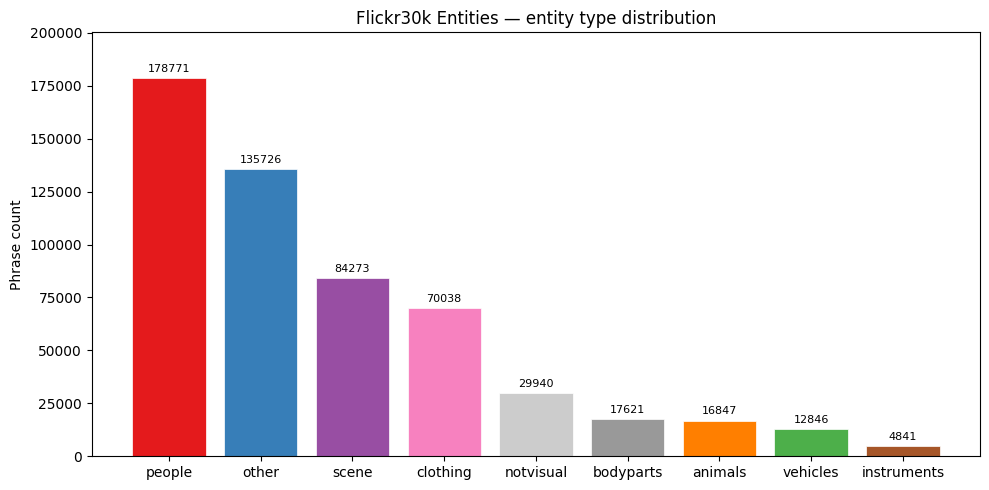

In [6]:
# ── 5. Entity type bar chart ──────────────────────────────────────────────────
labels, vals = zip(*entity_type_counts.most_common())
bar_colors   = [ENTITY_COLORS.get(l, '#aaaaaa') for l in labels]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, vals, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.bar_label(bars, fmt='%d', padding=3, fontsize=8)
ax.set_ylabel('Phrase count')
ax.set_title('Flickr30k Entities — entity type distribution')
ax.set_ylim(0, max(vals) * 1.12)
plt.tight_layout()
plt.show()

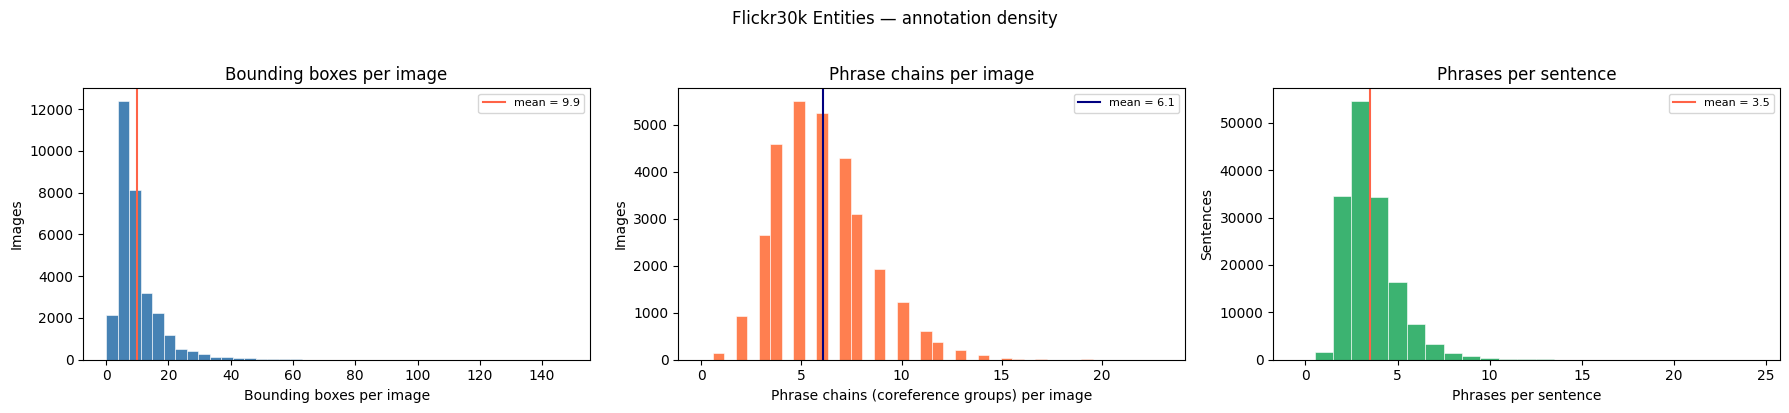

In [7]:
# ── 6. Bounding boxes & phrase chain distributions ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(boxes_per_image, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].axvline(boxes_per_image.mean(), color='tomato', linewidth=1.5,
                label=f'mean = {boxes_per_image.mean():.1f}')
axes[0].set_xlabel('Bounding boxes per image')
axes[0].set_ylabel('Images')
axes[0].set_title('Bounding boxes per image')
axes[0].legend(fontsize=8)

axes[1].hist(chains_per_image, bins=40, color='coral', edgecolor='white', linewidth=0.4)
axes[1].axvline(chains_per_image.mean(), color='navy', linewidth=1.5,
                label=f'mean = {chains_per_image.mean():.1f}')
axes[1].set_xlabel('Phrase chains (coreference groups) per image')
axes[1].set_ylabel('Images')
axes[1].set_title('Phrase chains per image')
axes[1].legend(fontsize=8)

axes[2].hist(phrases_per_sent, bins=range(0, phrases_per_sent.max() + 2),
             color='mediumseagreen', edgecolor='white', linewidth=0.4, align='left')
axes[2].axvline(phrases_per_sent.mean(), color='tomato', linewidth=1.5,
                label=f'mean = {phrases_per_sent.mean():.1f}')
axes[2].set_xlabel('Phrases per sentence')
axes[2].set_ylabel('Sentences')
axes[2].set_title('Phrases per sentence')
axes[2].legend(fontsize=8)

plt.suptitle('Flickr30k Entities — annotation density', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── 6a. Bounding-box area relative to image area ─────────────────────────────
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(bbox_area_ratios, bins=60, color='darkorange', edgecolor='white', linewidth=0.4)
ax.axvline(bbox_area_ratios.mean(), color='navy', linewidth=1.5,
           label=f'mean = {bbox_area_ratios.mean():.3f}')
ax.axvline(np.median(bbox_area_ratios), color='tomato', linewidth=1.5, linestyle='--',
           label=f'median = {np.median(bbox_area_ratios):.3f}')
ax.set_xlabel('Box area / image area')
ax.set_ylabel('Count')
ax.set_title(f'Bounding box relative size  (n = {len(bbox_area_ratios):,} boxes)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'min={bbox_area_ratios.min():.4f}  max={bbox_area_ratios.max():.4f}  '
      f'mean={bbox_area_ratios.mean():.4f}  median={np.median(bbox_area_ratios):.4f}')
print(f'Boxes covering >50% of image: {(bbox_area_ratios > 0.5).sum():,}  '
      f'({100*(bbox_area_ratios > 0.5).mean():.1f}%)')

In [ ]:
# ── 6b. % phrases with multiple bboxes / no bbox ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# histogram: boxes per grounded chain
max_show = min(int(chain_box_counts.max()), 10)
axes[0].hist(np.clip(chain_box_counts, 1, max_show),
             bins=range(1, max_show + 2), color='steelblue',
             edgecolor='white', linewidth=0.4, align='left')
axes[0].set_xlabel('Bounding boxes per grounded phrase chain')
axes[0].set_ylabel('Chains')
axes[0].set_title('Box multiplicity per phrase chain')
axes[0].set_xticks(range(1, max_show + 1))

# pie: chain grounding categories
n_single = int((chain_box_counts == 1).sum())
n_multi  = int((chain_box_counts  > 1).sum())
sizes  = [n_single, n_multi, n_nobox, n_scene]
labels = [f'1 box\n({n_single:,})', f'≥2 boxes\n({n_multi:,})',
          f'not visible\n({n_nobox:,})', f'scene\n({n_scene:,})']
axes[1].pie(sizes, labels=labels,
            colors=['steelblue', 'darkorange', 'lightgrey', 'mediumpurple'],
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 9})
axes[1].set_title('Phrase chain grounding categories')

plt.suptitle('Flickr30k Entities — phrase chain multiplicity', y=1.02)
plt.tight_layout()
plt.show()
print(f'Multi-box phrases: {n_multi:,} ({pct_multi_box:.1f}% of grounded chains)')
print(f'No-bbox phrases  : {n_nobox:,} ({pct_nobox:.1f}% of all chains)')

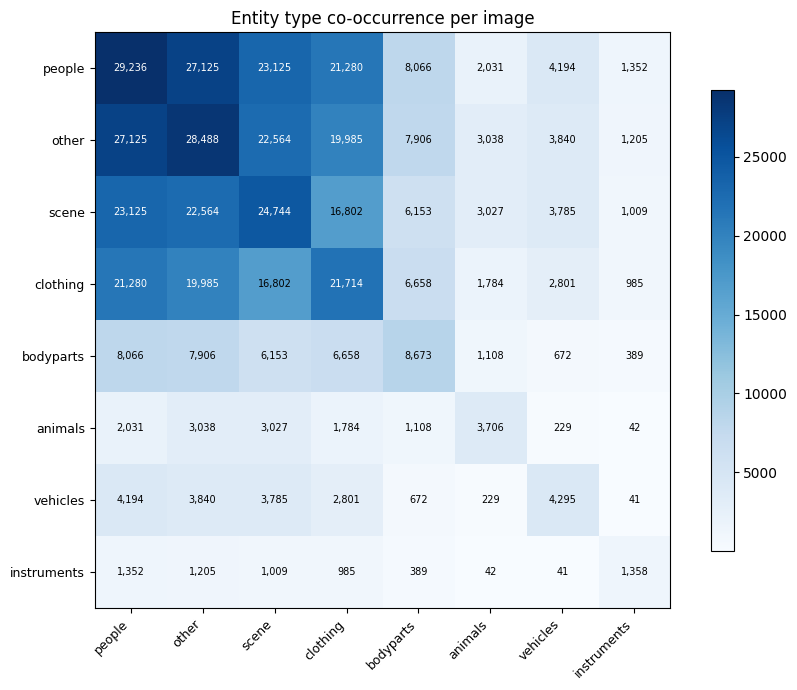

In [8]:
# ── 7. Co-occurrence heatmap: entity types that appear together per image ─────
entity_types_sorted = [t for t, _ in entity_type_counts.most_common() if t != 'notvisual']
n = len(entity_types_sorted)
cooc = np.zeros((n, n), dtype=int)
type_to_idx = {t: i for i, t in enumerate(entity_types_sorted)}

for row in data:
    stem      = row['filename'].replace('.jpg', '')
    sent_path = os.path.join(SENT_DIR, f'{stem}.txt')
    if not os.path.exists(sent_path):
        continue
    types_in_img = set()
    for sent in get_sentence_data(sent_path):
        for phrase in sent['phrases']:
            for ptype in phrase['phrase_type']:
                if ptype in type_to_idx:
                    types_in_img.add(ptype)
    types_list = list(types_in_img)
    for i, a in enumerate(types_list):
        for b in types_list[i:]:
            cooc[type_to_idx[a], type_to_idx[b]] += 1
            if a != b:
                cooc[type_to_idx[b], type_to_idx[a]] += 1

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cooc, cmap='Blues')
ax.set_xticks(range(n)); ax.set_xticklabels(entity_types_sorted, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(n)); ax.set_yticklabels(entity_types_sorted, fontsize=9)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{cooc[i,j]:,}', ha='center', va='center', fontsize=7,
                color='white' if cooc[i,j] > cooc.max() * 0.6 else 'black')
ax.set_title('Entity type co-occurrence per image')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

In [ ]:
# ── 8a. Head-noun vocabulary ──────────────────────────────────────────────────
# Head noun = last word of each phrase (lowercased). Simple but effective heuristic.
try:
    from wordcloud import WordCloud
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', '-q', 'install', 'wordcloud'])
    from wordcloud import WordCloud

top30 = head_noun_counter.most_common(30)
hn_words, hn_counts = zip(*top30)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].barh(hn_words[::-1], hn_counts[::-1], color='steelblue')
axes[0].set_xlabel('Frequency')
axes[0].set_title(f'Top-30 head nouns  (unique vocab = {len(head_noun_counter):,} tokens)')
axes[0].tick_params(axis='y', labelsize=8)

wc = WordCloud(width=700, height=350, background_color='white',
               colormap='viridis', max_words=150).generate_from_frequencies(head_noun_counter)
axes[1].imshow(wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Head-noun word cloud')

plt.tight_layout()
plt.show()
print(f'Unique head-noun vocabulary: {len(head_noun_counter):,} tokens')

In [ ]:
# ── 8b. FlickrEntitiesDataset — reusable PyTorch Dataset for training ─────────
import io as _io
import torch
from torch.utils.data import Dataset
from torchvision import transforms as T

class FlickrEntitiesDataset(Dataset):
    """Returns (image_tensor, phrase_box_list) per image.

    phrase_box_list is a list of (phrase_str, [x1, y1, x2, y2]) pairs.
    Multi-bbox phrases are expanded — one tuple per box.
    notvisual and scene phrases are excluded (no bbox available).

    Args:
        hf_data      : HuggingFace Dataset with image / filename / split columns.
        ann_dir      : path to flickr30k_entities Annotations/ directory.
        sent_dir     : path to flickr30k_entities Sentences/ directory.
        split_filter : 'train' | 'val' | 'test' | None (keep all).
        transform    : torchvision transform applied to PIL image.
    """

    _DEFAULT_TRANSFORM = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    def __init__(self, hf_data, ann_dir: str, sent_dir: str,
                 split_filter: str | None = 'train',
                 transform=None):
        self.ann_dir   = ann_dir
        self.sent_dir  = sent_dir
        self.transform = transform or self._DEFAULT_TRANSFORM
        self.rows = [r for r in hf_data if r['split'] == split_filter] \
                    if split_filter else list(hf_data)

    def __len__(self) -> int:
        return len(self.rows)

    def __getitem__(self, idx: int):
        row  = self.rows[idx]
        stem = row['filename'].replace('.jpg', '')

        # decode image
        raw = row['image']
        pil = raw if isinstance(raw, PILImage.Image) \
              else PILImage.open(_io.BytesIO(raw['bytes'])).convert('RGB')

        anns  = get_annotations(os.path.join(self.ann_dir,  f'{stem}.xml'))
        sents = get_sentence_data(os.path.join(self.sent_dir, f'{stem}.txt'))

        # one (phrase, box) tuple per box; skip notvisual / scene chains
        phrase_boxes: list[tuple[str, list[int]]] = []
        seen = set()
        for sent in sents:
            for phrase in sent['phrases']:
                pid = phrase['phrase_id']
                if pid in seen or pid not in anns['boxes']:
                    continue
                seen.add(pid)
                for box in anns['boxes'][pid]:
                    phrase_boxes.append((phrase['phrase'], box))

        return self.transform(pil), phrase_boxes

    @staticmethod
    def collate_fn(batch):
        """Stack images into a tensor; keep phrase_boxes as list-of-lists."""
        images      = torch.stack([b[0] for b in batch])
        phrase_boxes = [b[1] for b in batch]
        return images, phrase_boxes


# ── Smoke test ────────────────────────────────────────────────────────────────
_train_ds = FlickrEntitiesDataset(data, ANN_DIR, SENT_DIR, split_filter='train')
_val_ds   = FlickrEntitiesDataset(data, ANN_DIR, SENT_DIR, split_filter='val')
_test_ds  = FlickrEntitiesDataset(data, ANN_DIR, SENT_DIR, split_filter='test')

print(f'Train : {len(_train_ds):,} images')
print(f'Val   : {len(_val_ds):,} images')
print(f'Test  : {len(_test_ds):,} images')

_img, _pb = _train_ds[0]
print(f'\nSample image tensor : {_img.shape}  dtype={_img.dtype}')
print(f'Phrase-box pairs    : {len(_pb)}')
print(f'First 3 pairs       : {_pb[:3]}')

In [ ]:
# ── 9. Summary & write notes/dataset_stats.md ────────────────────────────────
import datetime
total_phrases = sum(entity_type_counts.values())
total_boxes   = int(boxes_per_image.sum())
med_area      = float(np.median(bbox_area_ratios))

lines = [
    '# Flickr30k Entities — Dataset Statistics',
    f'_Generated: {datetime.date.today()}_',
    '',
    '## Overview',
    '| Stat | Value |',
    '|------|-------|',
    f'| Images (parquet) | {len(boxes_per_image):,} |',
    f'| Total bounding boxes | {total_boxes:,} |',
    f'| Avg boxes / image | {boxes_per_image.mean():.1f} |',
    f'| Avg phrase chains / image | {chains_per_image.mean():.1f} |',
    f'| Total phrases (all types) | {total_phrases:,} |',
    f'| Avg phrases / sentence | {phrases_per_sent.mean():.1f} |',
    '',
    '## Phrase Chain Grounding',
    '| Category | Count | % of all chains |',
    '|----------|-------|-----------------|',
    f'| Grounded (≥1 box) | {n_chains_with_box:,} | {100*n_chains_with_box/n_total_chains:.1f}% |',
    f'| Multi-box (≥2 boxes) | {int((chain_box_counts>1).sum()):,} | {pct_multi_box:.1f}% of grounded |',
    f'| Not visible (no box) | {n_nobox:,} | {pct_nobox:.1f}% |',
    f'| Scene-level | {n_scene:,} | {pct_scene:.1f}% |',
    '',
    '## Bounding Box Sizes (relative to image area)',
    '| Stat | Value |',
    '|------|-------|',
    f'| Mean | {bbox_area_ratios.mean():.4f} ({bbox_area_ratios.mean()*100:.1f}%) |',
    f'| Median | {med_area:.4f} ({med_area*100:.1f}%) |',
    f'| Min | {bbox_area_ratios.min():.4f} |',
    f'| Max | {bbox_area_ratios.max():.4f} |',
    f'| Boxes > 50% image | {(bbox_area_ratios>0.5).sum():,} ({100*(bbox_area_ratios>0.5).mean():.1f}%) |',
    '',
    '## Vocabulary',
    '| Stat | Value |',
    '|------|-------|',
    f'| Unique head nouns | {len(head_noun_counter):,} |',
    f'| Top head noun | "{head_noun_counter.most_common(1)[0][0]}" ({head_noun_counter.most_common(1)[0][1]:,}x) |',
    '',
    '## Entity Type Distribution',
    '| Type | Count | % |',
    '|------|-------|---|',
    *[f'| {t} | {c:,} | {100*c/total_phrases:.1f}% |'
      for t, c in entity_type_counts.most_common()],
    '',
    '## Design Notes',
    f'- **People dominate** ({100*entity_type_counts["people"]/total_phrases:.1f}%): '
     'model will learn person-centric grounding first; monitor for bias.',
    f'- **{pct_scene:.1f}% of chains are scene-level** (whole image) — excluded from L_region training.',
    f'- **{pct_nobox:.1f}% not visible** — excluded from training (no ground-truth box).',
    f'- **Median box covers {med_area*100:.1f}% of image** — small enough for meaningful '
     'patch-level supervision with SigLIP-B/16 at 448px (grid ≈ 28×28 patches).',
    f'- **{pct_multi_box:.1f}% of grounded chains have ≥2 boxes** — treat each (phrase, box) '
     'as a separate training sample (per design doc).',
    f'- **Head-noun vocab: {len(head_noun_counter):,} tokens** — manageable; SigLIP text encoder '
     'handles sub-word tokenization so no extra vocab engineering needed.',
    '- Use the `split` column from the parquet for train/val/test — do not re-split.',
]

os.makedirs('notes', exist_ok=True)
NOTES_PATH = 'notes/dataset_stats.md'
with open(NOTES_PATH, 'w') as f:
    f.write('\n'.join(lines) + '\n')
print(f'Stats written → {NOTES_PATH}')
print()
print('\n'.join(lines))